## Original Elo Rating System

In [ ]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import sys
from scipy import stats


from sklearn.metrics import mean_squared_error
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, confusion_matrix, precision_score, recall_score, accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_predict, cross_val_score

from elo_grad import EloEstimator, Regressor
from elo_grad.sklearn import SKEloEstimator

print(f'Python {sys.version} on {sys.platform}.')

Python 3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:19:24) [Clang 18.1.8 ] on darwin.


In [2]:
def evaluate_model(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.show()

In [3]:
# import data
train_set = pl.read_csv("../data/processed/train_set.csv", try_parse_dates=True)
#train_set['date_game'] = pd.to_datetime(train_set['date_game'])

train_set = train_set.with_columns((24 * 60 * 60 * pl.col('date_game').cast(pl.Int64)).alias('t'))


In [4]:
train_set = train_set.with_columns(
    (pl.col('pts_main') > pl.col('pts_opp')).cast(pl.Int8).alias('result')
)
train_set.head()

date_game,game_id,team_id_main,team_abbreviation_main,team_wins_losses_main,pts_main,matchup_main,wl_main,fgm_main,fga_main,fg_pct_main,fg3m_main,fg3a_main,fg3_pct_main,ftm_main,fta_main,ft_pct_main,oreb_main,dreb_main,ast_main,stl_main,blk_main,tov_main,pf_main,plus_minus_main,team_id_opp,team_abbreviation_opp,team_wins_losses_opp,pts_opp,team_name_opp,matchup_opp,wl_opp,fgm_opp,fga_opp,fg_pct_opp,fg3m_opp,fg3a_opp,fg3_pct_opp,ftm_opp,fta_opp,ft_pct_opp,oreb_opp,dreb_opp,reb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,plus_minus_opp,season_id,is_playoffs,elo_main_pre_538,elo_main_post_538,win_equiv,elo_opp_pre_538,elo_opp_post_538,game_result,forecast,t,result
date,i64,i64,str,str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,str,f64,i64,i8
1981-05-05,48000048,1610612738,"""BOS""","""1-0""",98.0,"""BOS vs. HOU""","""W""",41.0,95.0,0.432,0.0,1.0,0.0,16.0,20.0,0.8,25.0,29.0,23.0,6.0,5.0,19.0,21.0,3,1610612745,"""HOU""","""0-1""",95.0,"""Houston Rockets""","""HOU @ BOS""","""L""",42.0,99.0,0.424,0.0,2.0,0.0,11.0,14.0,0.786,19.0,23.0,42.0,23.0,15.0,3.0,10.0,20.0,-3,41980,1,1667.918,1670.298,58.218166,1573.3342,1570.9542,"""W""",0.75401,357868800,1
1981-05-05,48000048,1610612745,"""HOU""","""0-1""",95.0,"""HOU @ BOS""","""L""",42.0,99.0,0.424,0.0,2.0,0.0,11.0,14.0,0.786,19.0,23.0,23.0,15.0,3.0,10.0,20.0,-3,1610612738,"""BOS""","""1-0""",98.0,"""Boston Celtics""","""BOS vs. HOU""","""W""",41.0,95.0,0.432,0.0,1.0,0.0,16.0,20.0,0.8,25.0,29.0,54.0,23.0,6.0,5.0,19.0,21.0,3,41980,1,1573.3342,1570.9542,48.834915,1667.918,1670.298,"""L""",0.24599,357868800,0
1981-05-07,48000049,1610612738,"""BOS""","""1-1""",90.0,"""HOU @ BOS""","""W""",34.0,85.0,0.4,2.0,2.0,1.0,22.0,32.0,0.688,13.0,22.0,16.0,6.0,8.0,9.0,17.0,2,1610612745,"""HOU""","""1-1""",92.0,"""Boston Celtics""","""BOS vs. HOU""","""L""",41.0,82.0,0.5,0.0,3.0,0.0,8.0,13.0,0.615,14.0,34.0,48.0,17.0,6.0,7.0,22.0,27.0,-2,41980,1,1670.298,1661.5709,57.457176,1570.9542,1579.6813,"""L""",0.759057,358041600,0
1981-05-07,48000049,1610612745,"""HOU""","""1-1""",92.0,"""BOS vs. HOU""","""L""",41.0,82.0,0.5,0.0,3.0,0.0,8.0,13.0,0.615,14.0,34.0,17.0,6.0,7.0,22.0,27.0,-2,1610612738,"""BOS""","""1-1""",90.0,"""Houston Rockets""","""HOU @ BOS""","""W""",34.0,85.0,0.4,2.0,2.0,1.0,22.0,32.0,0.688,13.0,22.0,35.0,16.0,6.0,8.0,9.0,17.0,2,41980,1,1570.9542,1579.6813,49.71302,1670.298,1661.5709,"""W""",0.240943,358041600,1
1981-05-09,48000050,1610612738,"""BOS""","""2-1""",94.0,"""HOU vs. BOS""","""L""",24.0,79.0,0.304,0.0,1.0,0.0,23.0,31.0,0.742,19.0,29.0,10.0,6.0,9.0,21.0,19.0,-23,1610612745,"""HOU""","""1-2""",71.0,"""Boston Celtics""","""BOS @ HOU""","""W""",40.0,89.0,0.449,2.0,3.0,0.667,12.0,19.0,0.632,16.0,28.0,44.0,24.0,12.0,7.0,11.0,25.0,23,41980,1,1661.5709,1680.8596,59.120193,1579.6813,1560.3926,"""W""",0.4739607,358214400,1


### Fit original Elo-rating model

In [ ]:
# Fit Elo regression
original_elo = EloEstimator(
    k_factor=20, 
    beta=200,
    default_init_rating=1505, # Following 538's default starting poisition
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="result",
    date_col="t",
    track_rating_history=True
)
# Get expected scores
expected_scores = original_elo.predict_proba(train_set)
# Get final ratings (of form (timestamp, rating)) for home advantage
ratings = original_elo.model.ratings

In [7]:
# Fit the estimator
model_fit = original_elo.fit(train_set)

# Get predictions
preds = original_elo.predict(train_set)

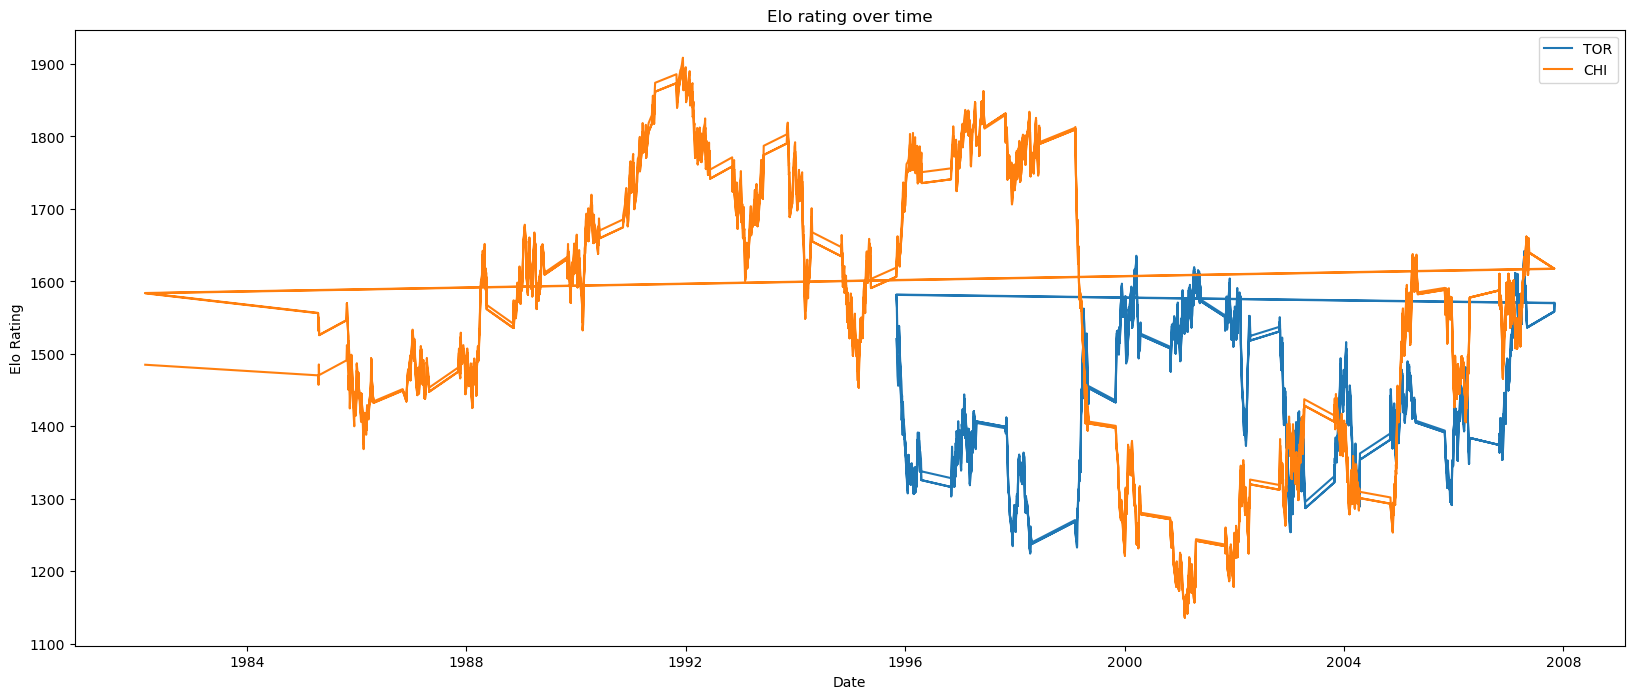

In [8]:
fig, ax = plt.subplots(figsize=(20, 8))
original_elo.plot(['TOR', 'CHI'], ax=ax)
plt.show()

In [9]:
y_val_pred = original_elo.predict_proba(train_set)[:, 1]
print(f"Test set log-loss: {log_loss(train_set['result'], y_val_pred):.4f}")

Test set log-loss: 0.6376


In [10]:
confusion_matrix(train_set['result'], y_val_pred.round())

array([[11150,  6129],
       [ 6126, 11149]])

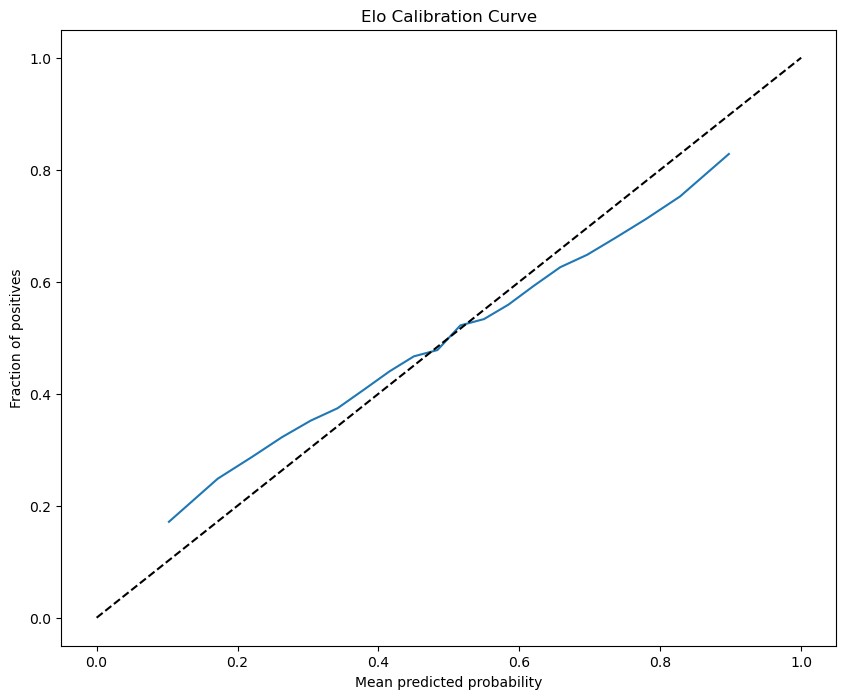

In [11]:
prob_true, prob_pred = calibration_curve(train_set['result'], y_val_pred, n_bins=20, strategy='quantile')

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(prob_pred, prob_true)
ax.plot([0, 1], [0, 1], color='black', linestyle='--')
ax.set(
    title='Elo Calibration Curve',
    xlabel='Mean predicted probability',
    ylabel='Fraction of positives',
)

plt.show()

In [12]:
evaluate_model(train_set['result'], y_val_pred.round())

NameError: name 'precision_score' is not defined